In [32]:
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import os

# ===============================
# ✅ 1. Dataset Paths
# ===============================
train_dir = "/kaggle/input/dataset/Combined Dataset/train"
val_dir = "/kaggle/input/dataset/Combined Dataset/test"

img_size = (224, 224)
batch_size = 32

# ===============================
# ✅ 2. Load Datasets
# ===============================
train_ds = image_dataset_from_directory(
    train_dir,
    image_size=img_size,
    batch_size=batch_size,
    shuffle=True
)

val_ds = image_dataset_from_directory(
    val_dir,
    image_size=img_size,
    batch_size=batch_size
)

num_classes = len(train_ds.class_names)
print("🧩 Classes:", train_ds.class_names)
print("🔢 Number of classes:", num_classes)

# Prefetch for better performance
train_ds = train_ds.prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.prefetch(tf.data.AUTOTUNE)

# ===============================
# ✅ 3. Data Augmentation
# ===============================
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.15),
    tf.keras.layers.RandomZoom(0.15),
])

# ===============================
# ✅ 4. Base Model (Transfer Learning)
# ===============================
base_model = EfficientNetB0(
    include_top=False,
    input_shape=(224, 224, 3),
    weights='imagenet'
)
base_model.trainable = False  # Freeze for first phase

# ===============================
# ✅ 5. Model Architecture
# ===============================
inputs = tf.keras.Input(shape=(224, 224, 3))
x = data_augmentation(inputs)
x = base_model(x, training=False)
x = GlobalAveragePooling2D()(x)
x = Dropout(0.4)(x)
outputs = Dense(num_classes, activation="softmax")(x)

model = Model(inputs, outputs)

# ===============================
# ✅ 6. Compile (Phase 1)
# ===============================
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# ===============================
# ✅ 7. Callbacks
# ===============================
checkpoint_path = "best_model.keras"
callbacks = [
    EarlyStopping(monitor="val_accuracy", patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.2, patience=3, verbose=1),
    ModelCheckpoint(checkpoint_path, monitor="val_accuracy", save_best_only=True)
]

# ===============================
# ✅ 8. Training Phase 1 (Frozen Base)
# ===============================
print("\n🔹 Phase 1: Training top layers...")
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=callbacks
)

# ===============================
# ✅ 9. Fine-Tuning Phase (Unfreeze base)
# ===============================
print("\n🔹 Phase 2: Fine-tuning base model...")
base_model.trainable = True
for layer in base_model.layers[:100]:
    layer.trainable = False  # Freeze lower layers for stability

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

fine_tune_history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=callbacks
)

# ===============================
# ✅ 10. Evaluate Final Model
# ===============================
val_loss, val_acc = model.evaluate(val_ds)
print(f"\n🏁 Final Validation Accuracy: {val_acc:.4f}")
print(f"📉 Final Validation Loss: {val_loss:.4f}")

# ===============================
# ✅ 11. Save Final Model
# ===============================
model.save("/kaggle/working/final_alzheimers_model.keras")
print("\n💾 Model saved successfully as 'final_alzheimers_model.keras'!")


Found 19165 files belonging to 4 classes.
Found 2558 files belonging to 4 classes.
🧩 Classes: ['Mild Impairment', 'Moderate Impairment', 'No Impairment', 'Very Mild Impairment']
🔢 Number of classes: 4
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

🔹 Phase 1: Training top layers...
Epoch 1/10


E0000 00:00:1762028496.635986      37 meta_optimizer.cc:966] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_8_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


599/599 ━━━━━━━━━━━━━━━━━━━━ 69s 87ms/step - accuracy: 0.5475 - loss: 1.0567 - val_accuracy: 0.5231 - val_loss: 1.0052 - learning_rate: 0.0010
Epoch 2/10
599/599 ━━━━━━━━━━━━━━━━━━━━ 49s 81ms/step - accuracy: 0.6657 - loss: 0.7947 - val_accuracy: 0.5450 - val_loss: 1.0016 - learning_rate: 0.0010
Epoch 3/10
599/599 ━━━━━━━━━━━━━━━━━━━━ 50s 83ms/step - accuracy: 0.6865 - loss: 0.7470 - val_accuracy: 0.5481 - val_loss: 0.9723 - learning_rate: 0.0010
Epoch 4/10
599/599 ━━━━━━━━━━━━━━━━━━━━ 49s 82ms/step - accuracy: 0.6895 - loss: 0.7304 - val_accuracy: 0.5450 - val_loss: 0.9841 - learning_rate: 0.0010
Epoch 5/10
599/599 ━━━━━━━━━━━━━━━━━━━━ 49s 82ms/step - accuracy: 0.6956 - loss: 0.7246 - val_accuracy: 0.5410 - val_loss: 0.9903 - learning_rate: 0.0010
Epoch 6/10
599/599 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.6932 - loss: 0.7200
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.00020000000949949026.
599/599 ━━━━━━━━━━━━━━━━━━━━ 49s 82ms/step - accuracy: 0.6932 - loss: 0.7200 

E0000 00:00:1762029030.417054      37 meta_optimizer.cc:966] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_8_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


599/599 ━━━━━━━━━━━━━━━━━━━━ 143s 175ms/step - accuracy: 0.6942 - loss: 0.7240 - val_accuracy: 0.5692 - val_loss: 0.9215 - learning_rate: 1.0000e-04
Epoch 2/15
599/599 ━━━━━━━━━━━━━━━━━━━━ 100s 167ms/step - accuracy: 0.8258 - loss: 0.4033 - val_accuracy: 0.6177 - val_loss: 0.8689 - learning_rate: 1.0000e-04
Epoch 3/15
599/599 ━━━━━━━━━━━━━━━━━━━━ 101s 168ms/step - accuracy: 0.8619 - loss: 0.3209 - val_accuracy: 0.7232 - val_loss: 0.6595 - learning_rate: 1.0000e-04
Epoch 4/15
599/599 ━━━━━━━━━━━━━━━━━━━━ 100s 167ms/step - accuracy: 0.8953 - loss: 0.2534 - val_accuracy: 0.7670 - val_loss: 0.5959 - learning_rate: 1.0000e-04
Epoch 5/15
599/599 ━━━━━━━━━━━━━━━━━━━━ 100s 167ms/step - accuracy: 0.9238 - loss: 0.1952 - val_accuracy: 0.7756 - val_loss: 0.5382 - learning_rate: 1.0000e-04
Epoch 6/15
599/599 ━━━━━━━━━━━━━━━━━━━━ 100s 167ms/step - accuracy: 0.9455 - loss: 0.1413 - val_accuracy: 0.8726 - val_loss: 0.3103 - learning_rate: 1.0000e-04
Epoch 7/15
599/599 ━━━━━━━━━━━━━━━━━━━━ 100s 167ms/

# Plot Training Curves (Accuracy & Loss)****

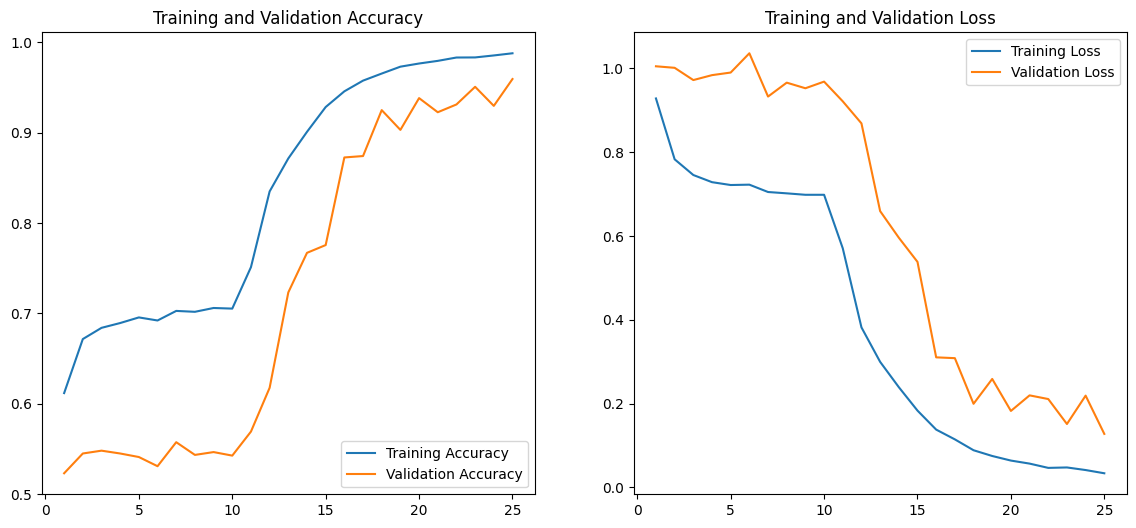

In [33]:
import matplotlib.pyplot as plt

# Combine both histories
acc = history.history['accuracy'] + fine_tune_history.history['accuracy']
val_acc = history.history['val_accuracy'] + fine_tune_history.history['val_accuracy']
loss = history.history['loss'] + fine_tune_history.history['loss']
val_loss = history.history['val_loss'] + fine_tune_history.history['val_loss']

epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(14, 6))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')

plt.show()


# Confusion Matrix + Classification Report

Found 2558 files belonging to 4 classes.
✅ Class names: ['Mild Impairment', 'Moderate Impairment', 'No Impairment', 'Very Mild Impairment']
80/80 ━━━━━━━━━━━━━━━━━━━━ 11s 99ms/step


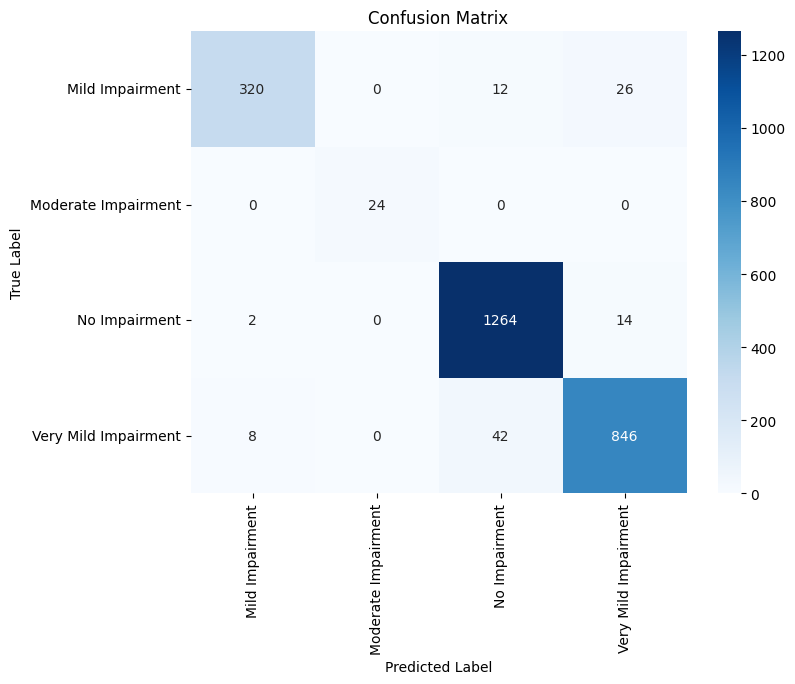


📊 Classification Report:

                      precision    recall  f1-score   support

     Mild Impairment       0.97      0.89      0.93       358
 Moderate Impairment       1.00      1.00      1.00        24
       No Impairment       0.96      0.99      0.97      1280
Very Mild Impairment       0.95      0.94      0.95       896

            accuracy                           0.96      2558
           macro avg       0.97      0.96      0.96      2558
        weighted avg       0.96      0.96      0.96      2558



In [35]:
import numpy as np
import tensorflow as tf
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Recreate val_ds without prefetch so we can access class names
val_dir = "/kaggle/input/dataset/Combined Dataset/test"
img_size = (224, 224)
batch_size = 32

val_raw = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    image_size=img_size,
    batch_size=batch_size,
    shuffle=False
)

class_names = val_raw.class_names
print("✅ Class names:", class_names)

# Load the model
model = tf.keras.models.load_model("/kaggle/working/final_alzheimers_model.keras")

# Get true labels and predictions
y_true = np.concatenate([y for x, y in val_raw], axis=0)
y_pred_probs = model.predict(val_raw)
y_pred = np.argmax(y_pred_probs, axis=1)

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

# Classification report
print("\n📊 Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))


# Export for Deployment

**B. Convert to ONNX (.onnx)**

In [37]:
!pip install tf2onnx

import tf2onnx

model = tf.keras.models.load_model("/kaggle/working/final_alzheimers_model.keras")

spec = (tf.TensorSpec((None, 224, 224, 3), tf.float32, name="input"),)
output_path = "/kaggle/working/final_alzheimers_model.onnx"

model_proto, _ = tf2onnx.convert.from_keras(model, input_signature=spec, output_path=output_path)
print("✅ Model converted to ONNX and saved as 'final_alzheimers_model.onnx'")


INFO: pip is looking at multiple versions of onnx to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 455.8/455.8 kB 12.1 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.0/16.0 MB 57.2 MB/s eta 0:00:0000:0100:01m
  Attempting uninstall: onnx
    Found existing installation: onnx 1.18.0
    Uninstalling onnx-1.18.0:
      Successfully uninstalled onnx-1.18.0


I0000 00:00:1762031345.319076      37 devices.cc:67] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 2
I0000 00:00:1762031345.319271      37 single_machine.cc:361] Starting new session
I0000 00:00:1762031345.321508      37 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1762031345.321743      37 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
I0000 00:00:1762031348.502393      37 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1762031348.502713      37 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 M

✅ Model converted to ONNX and saved as 'final_alzheimers_model.onnx'


# Plotting loss, accuracy , confusion matrix and classfication report

🖼️ Found the following plot images:

 - loss_curve.png


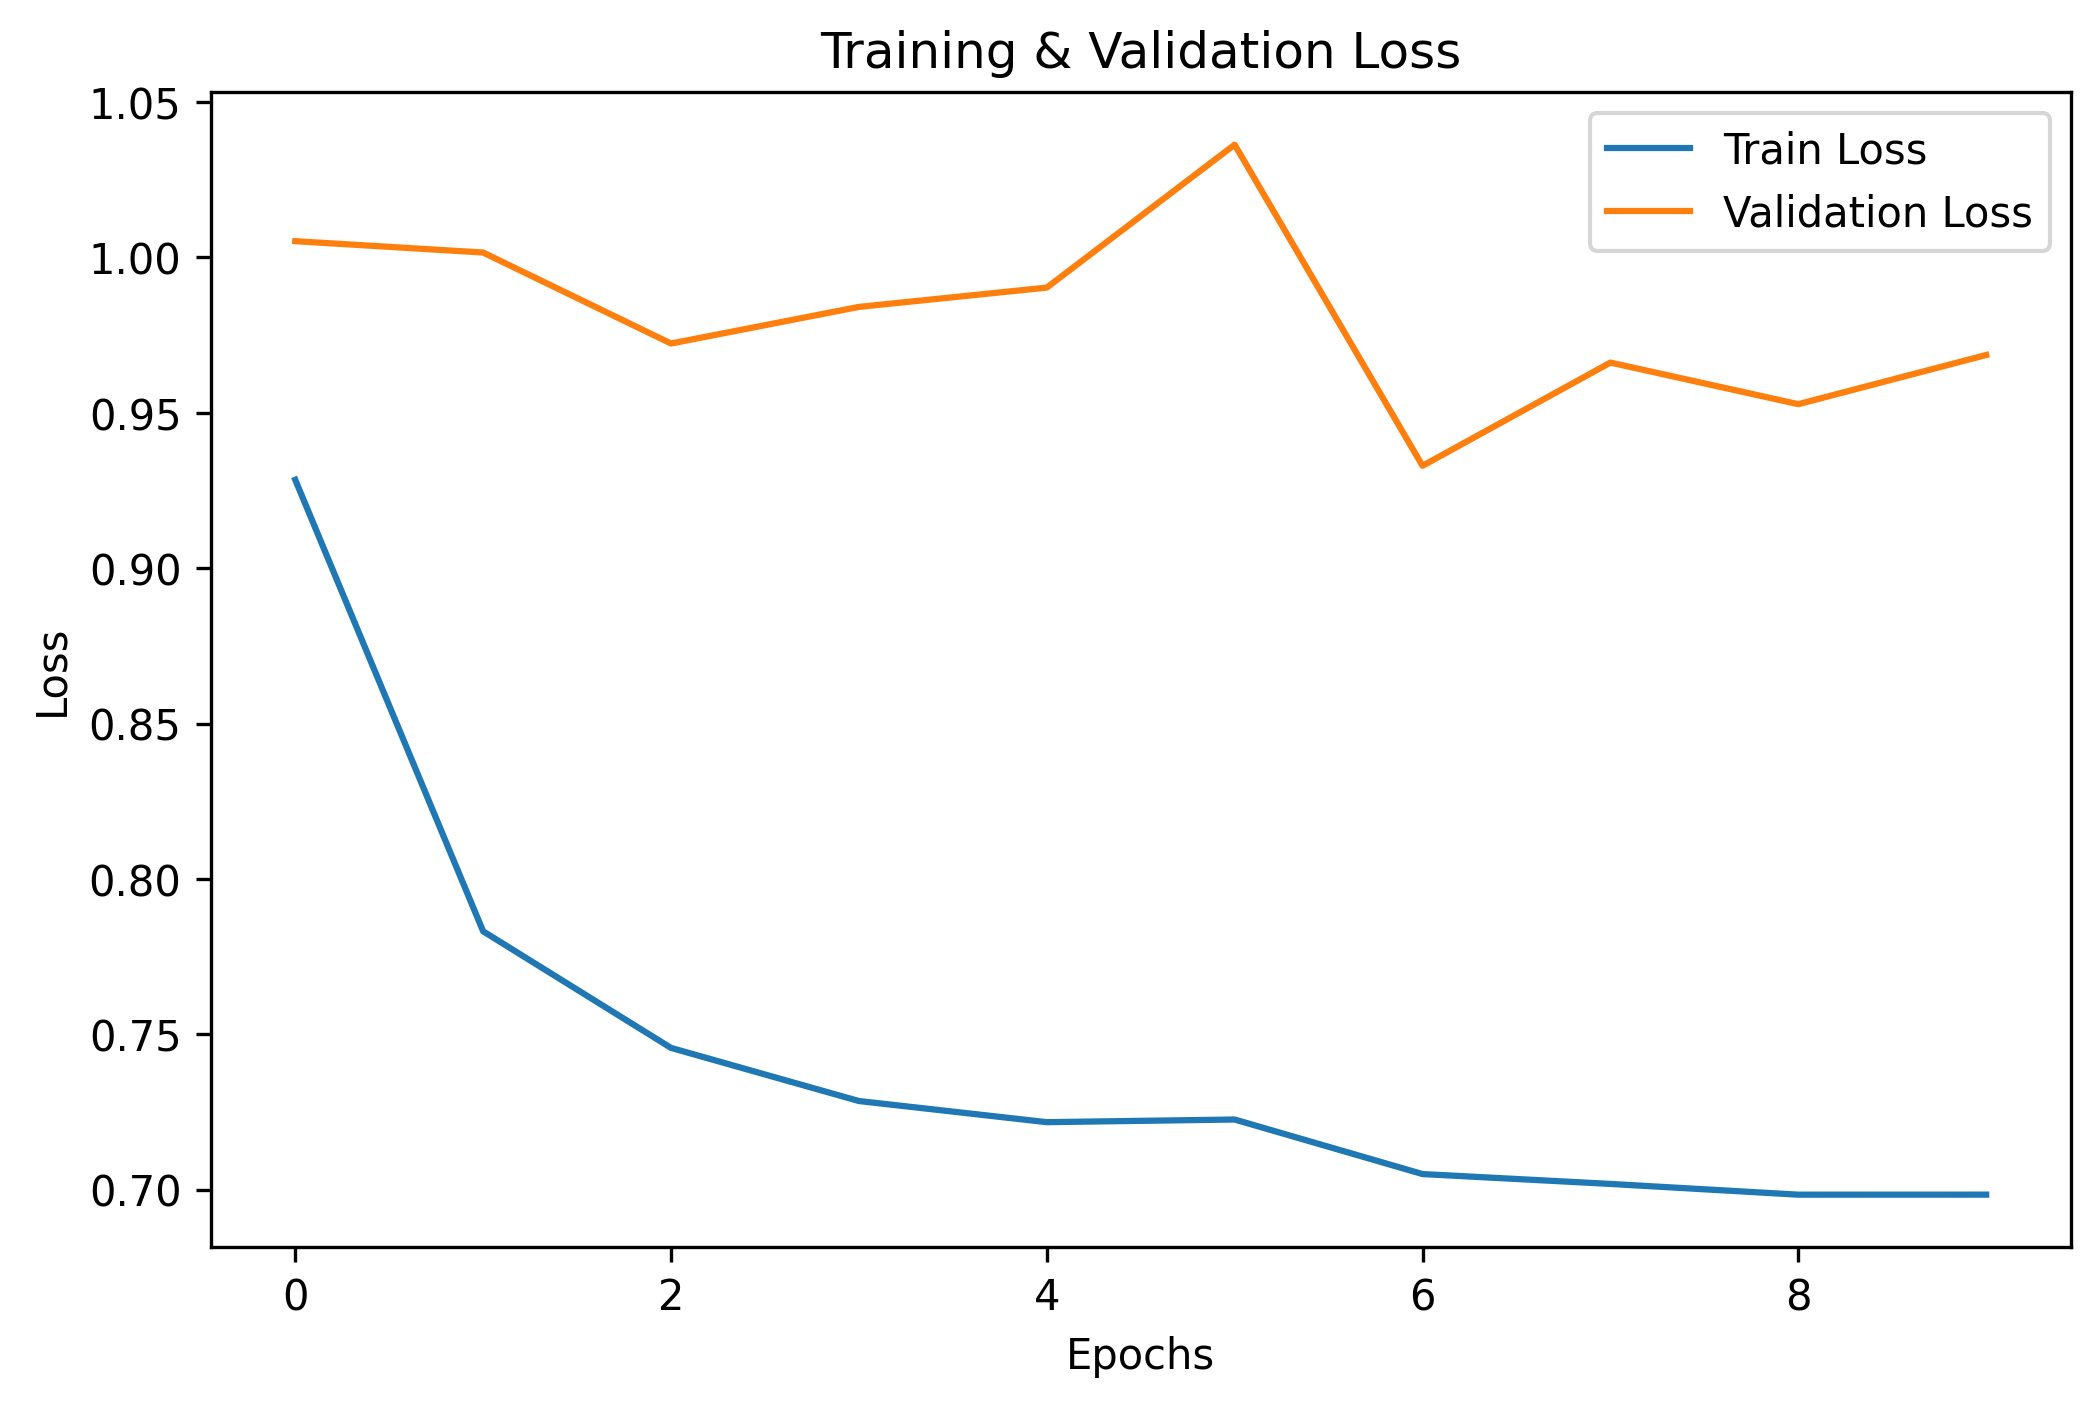

 - accuracy_curve.png


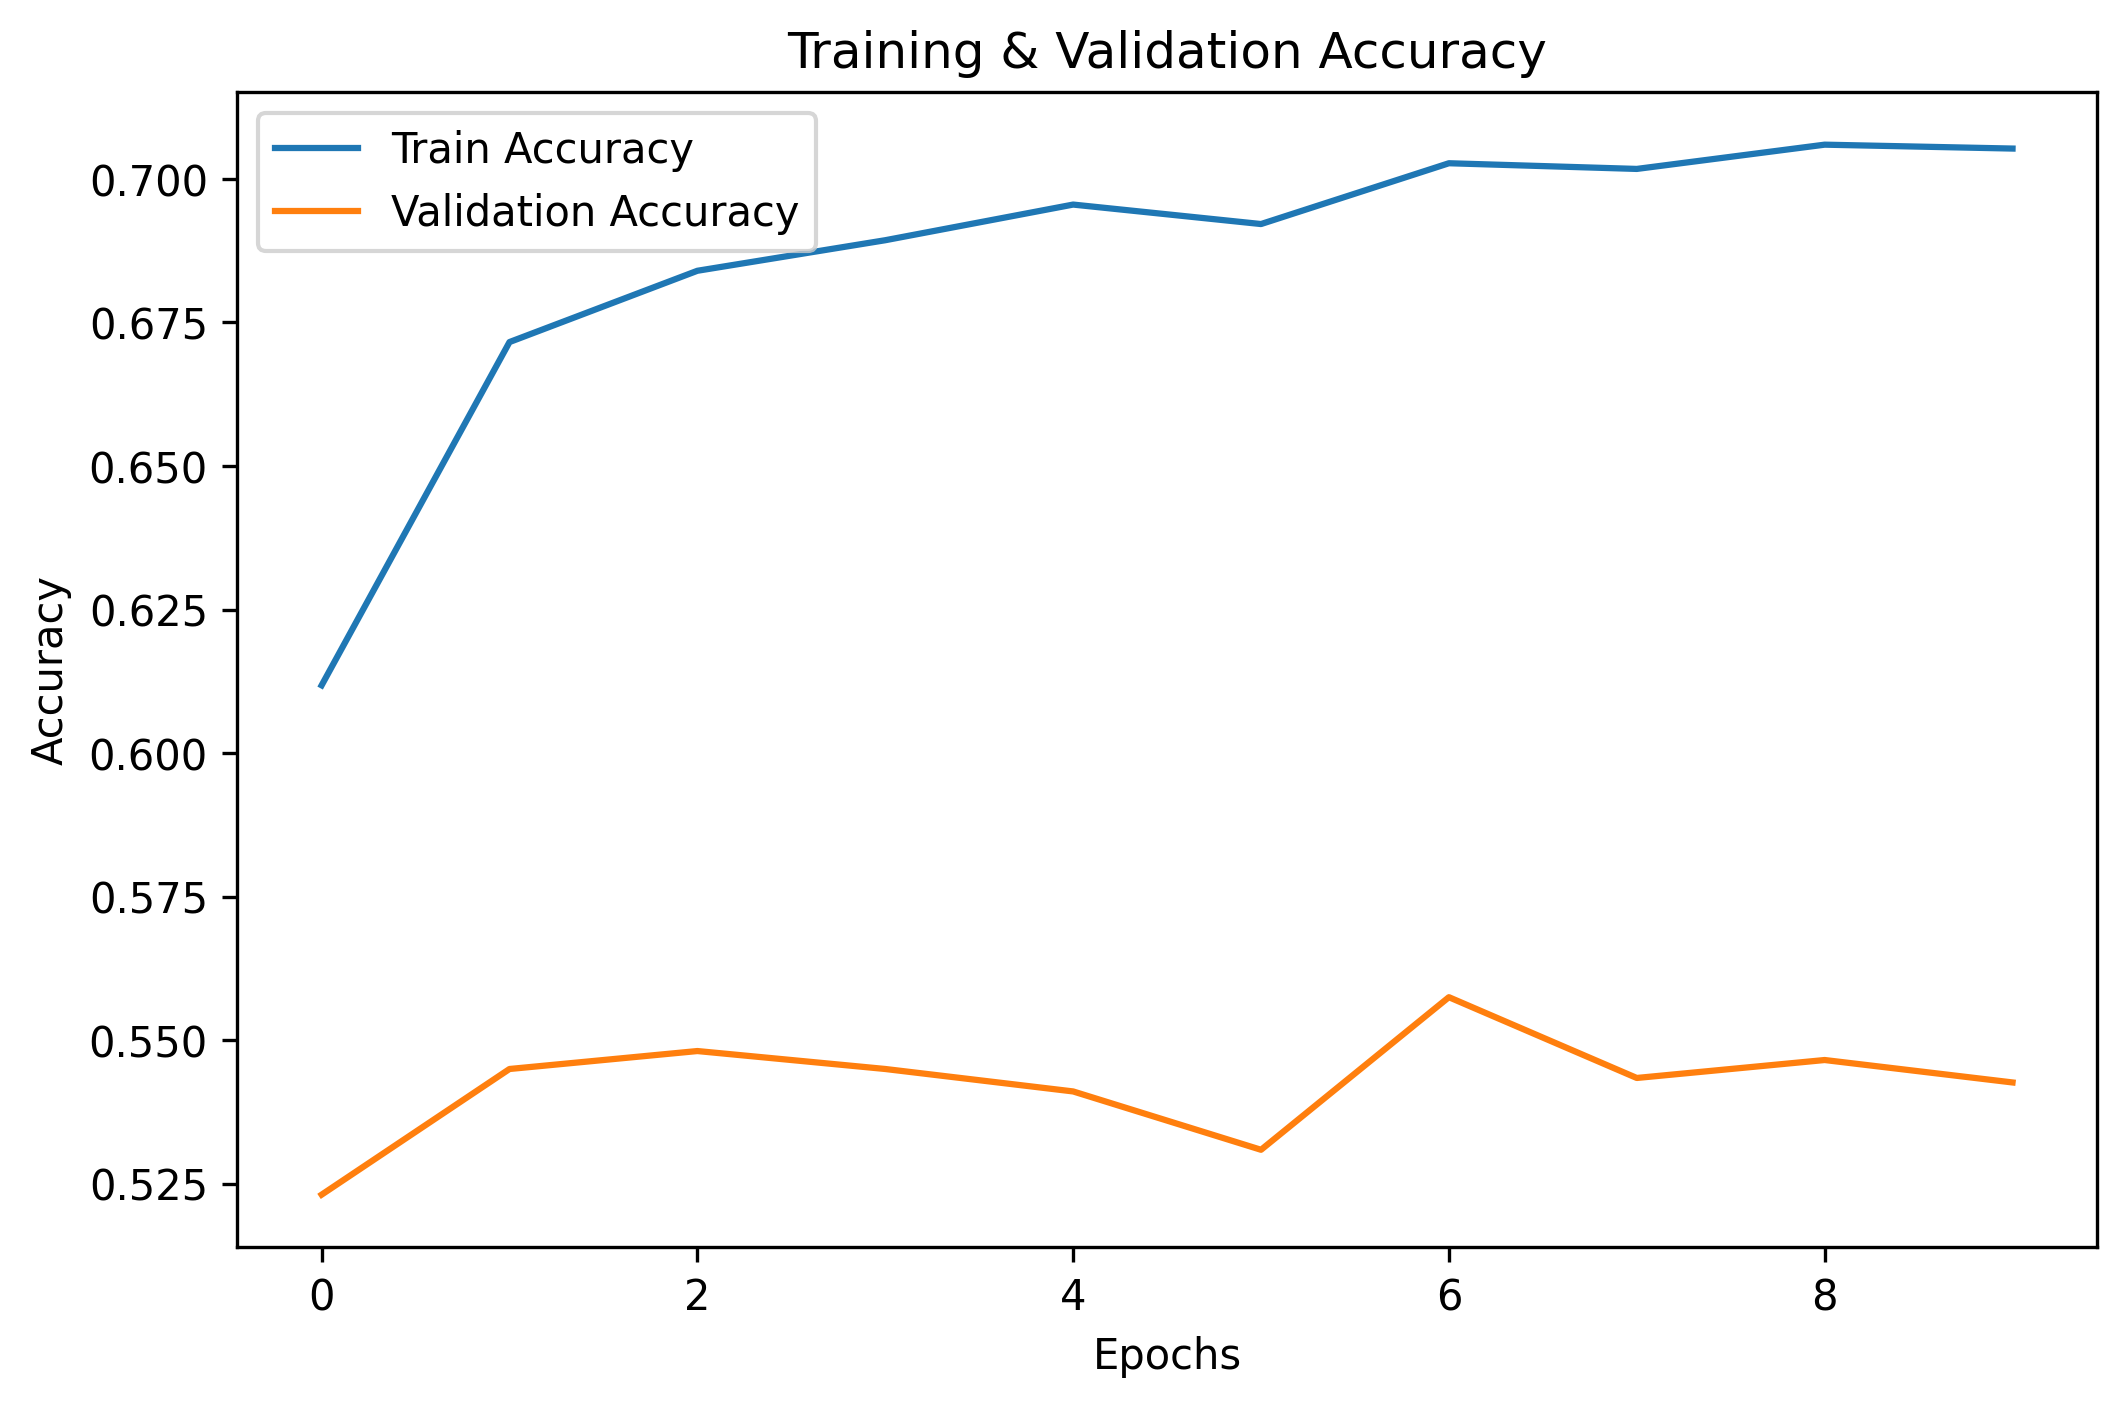

 - classification_metrics.png


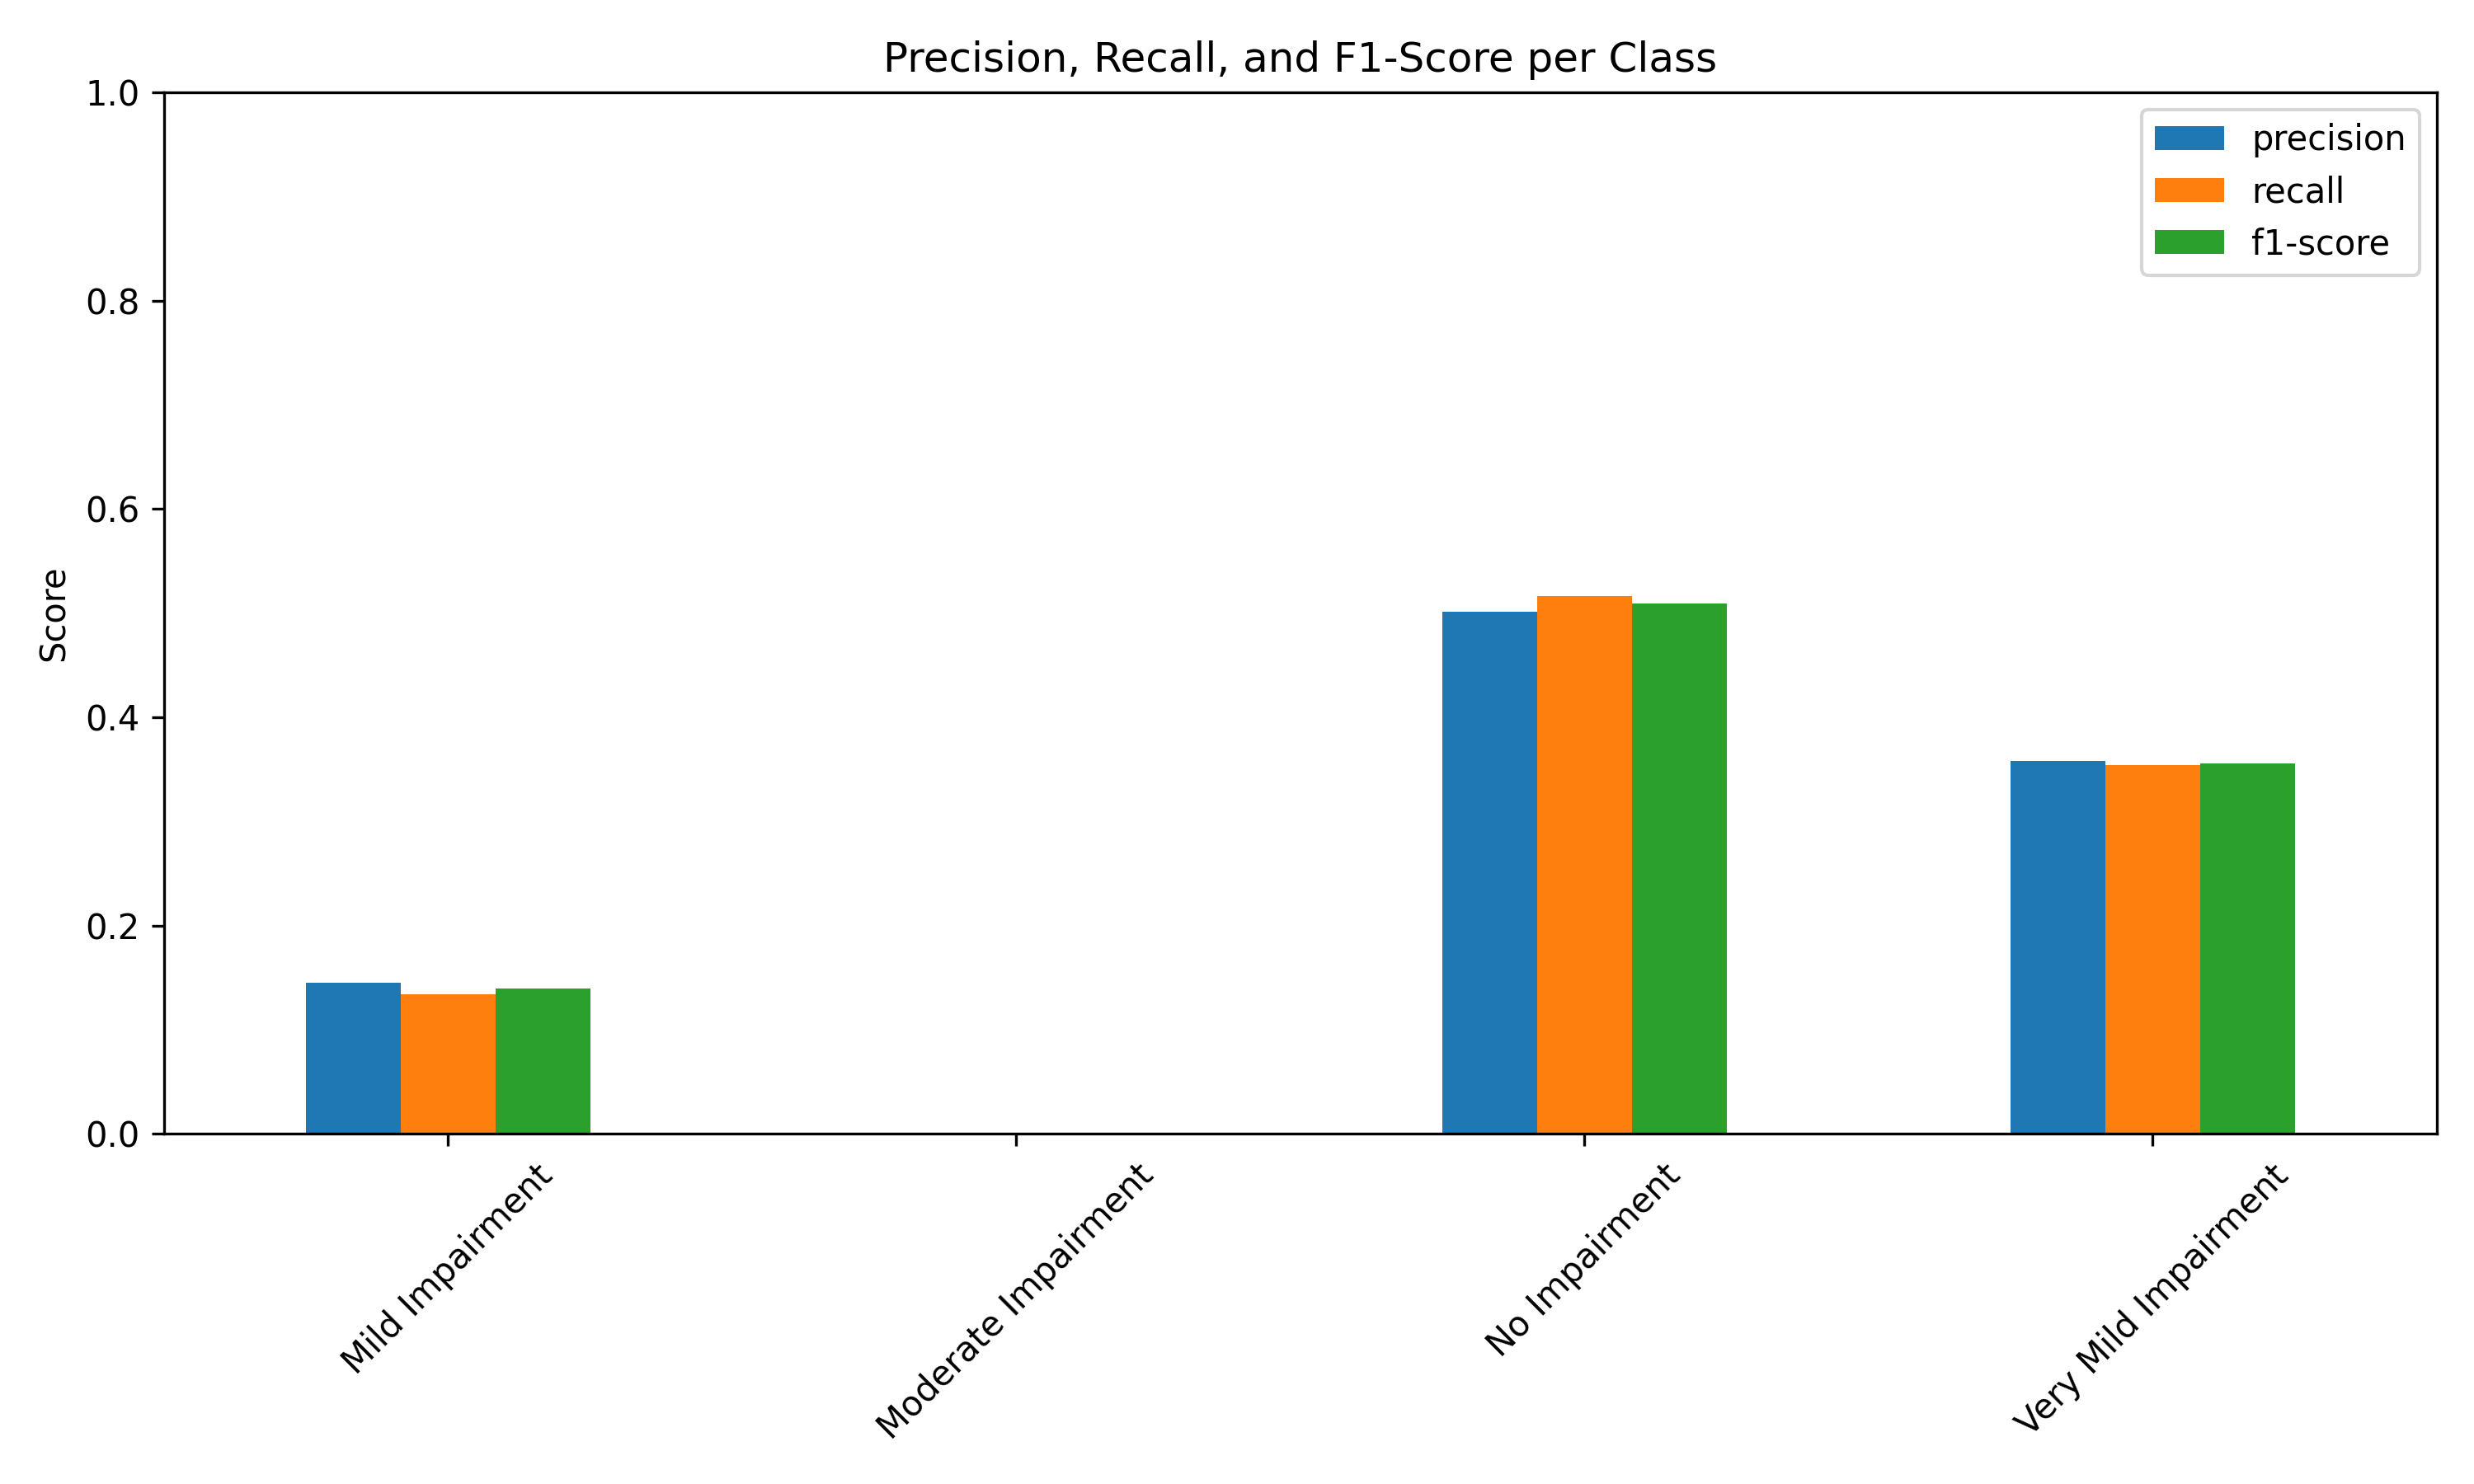

 - classification_report_table.png


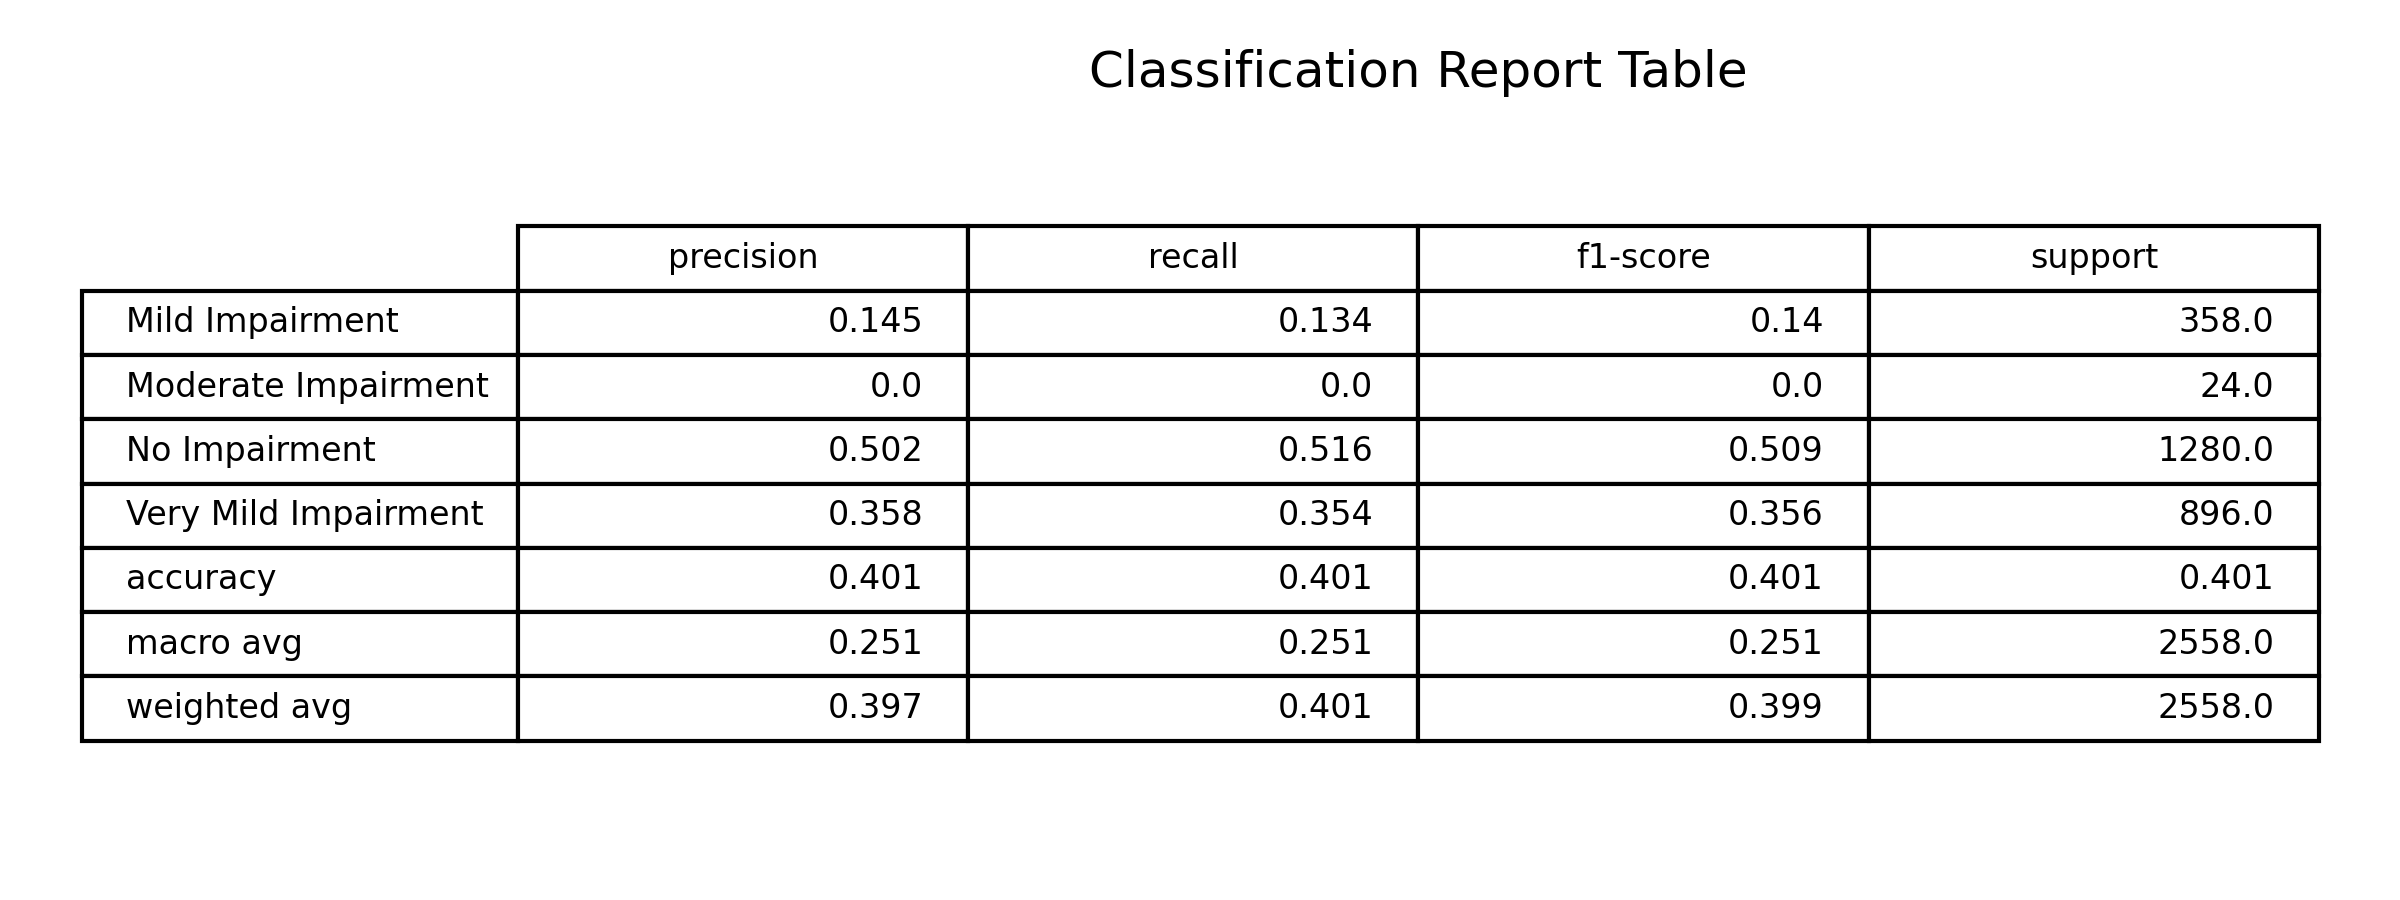

 - confusion_matrix.png


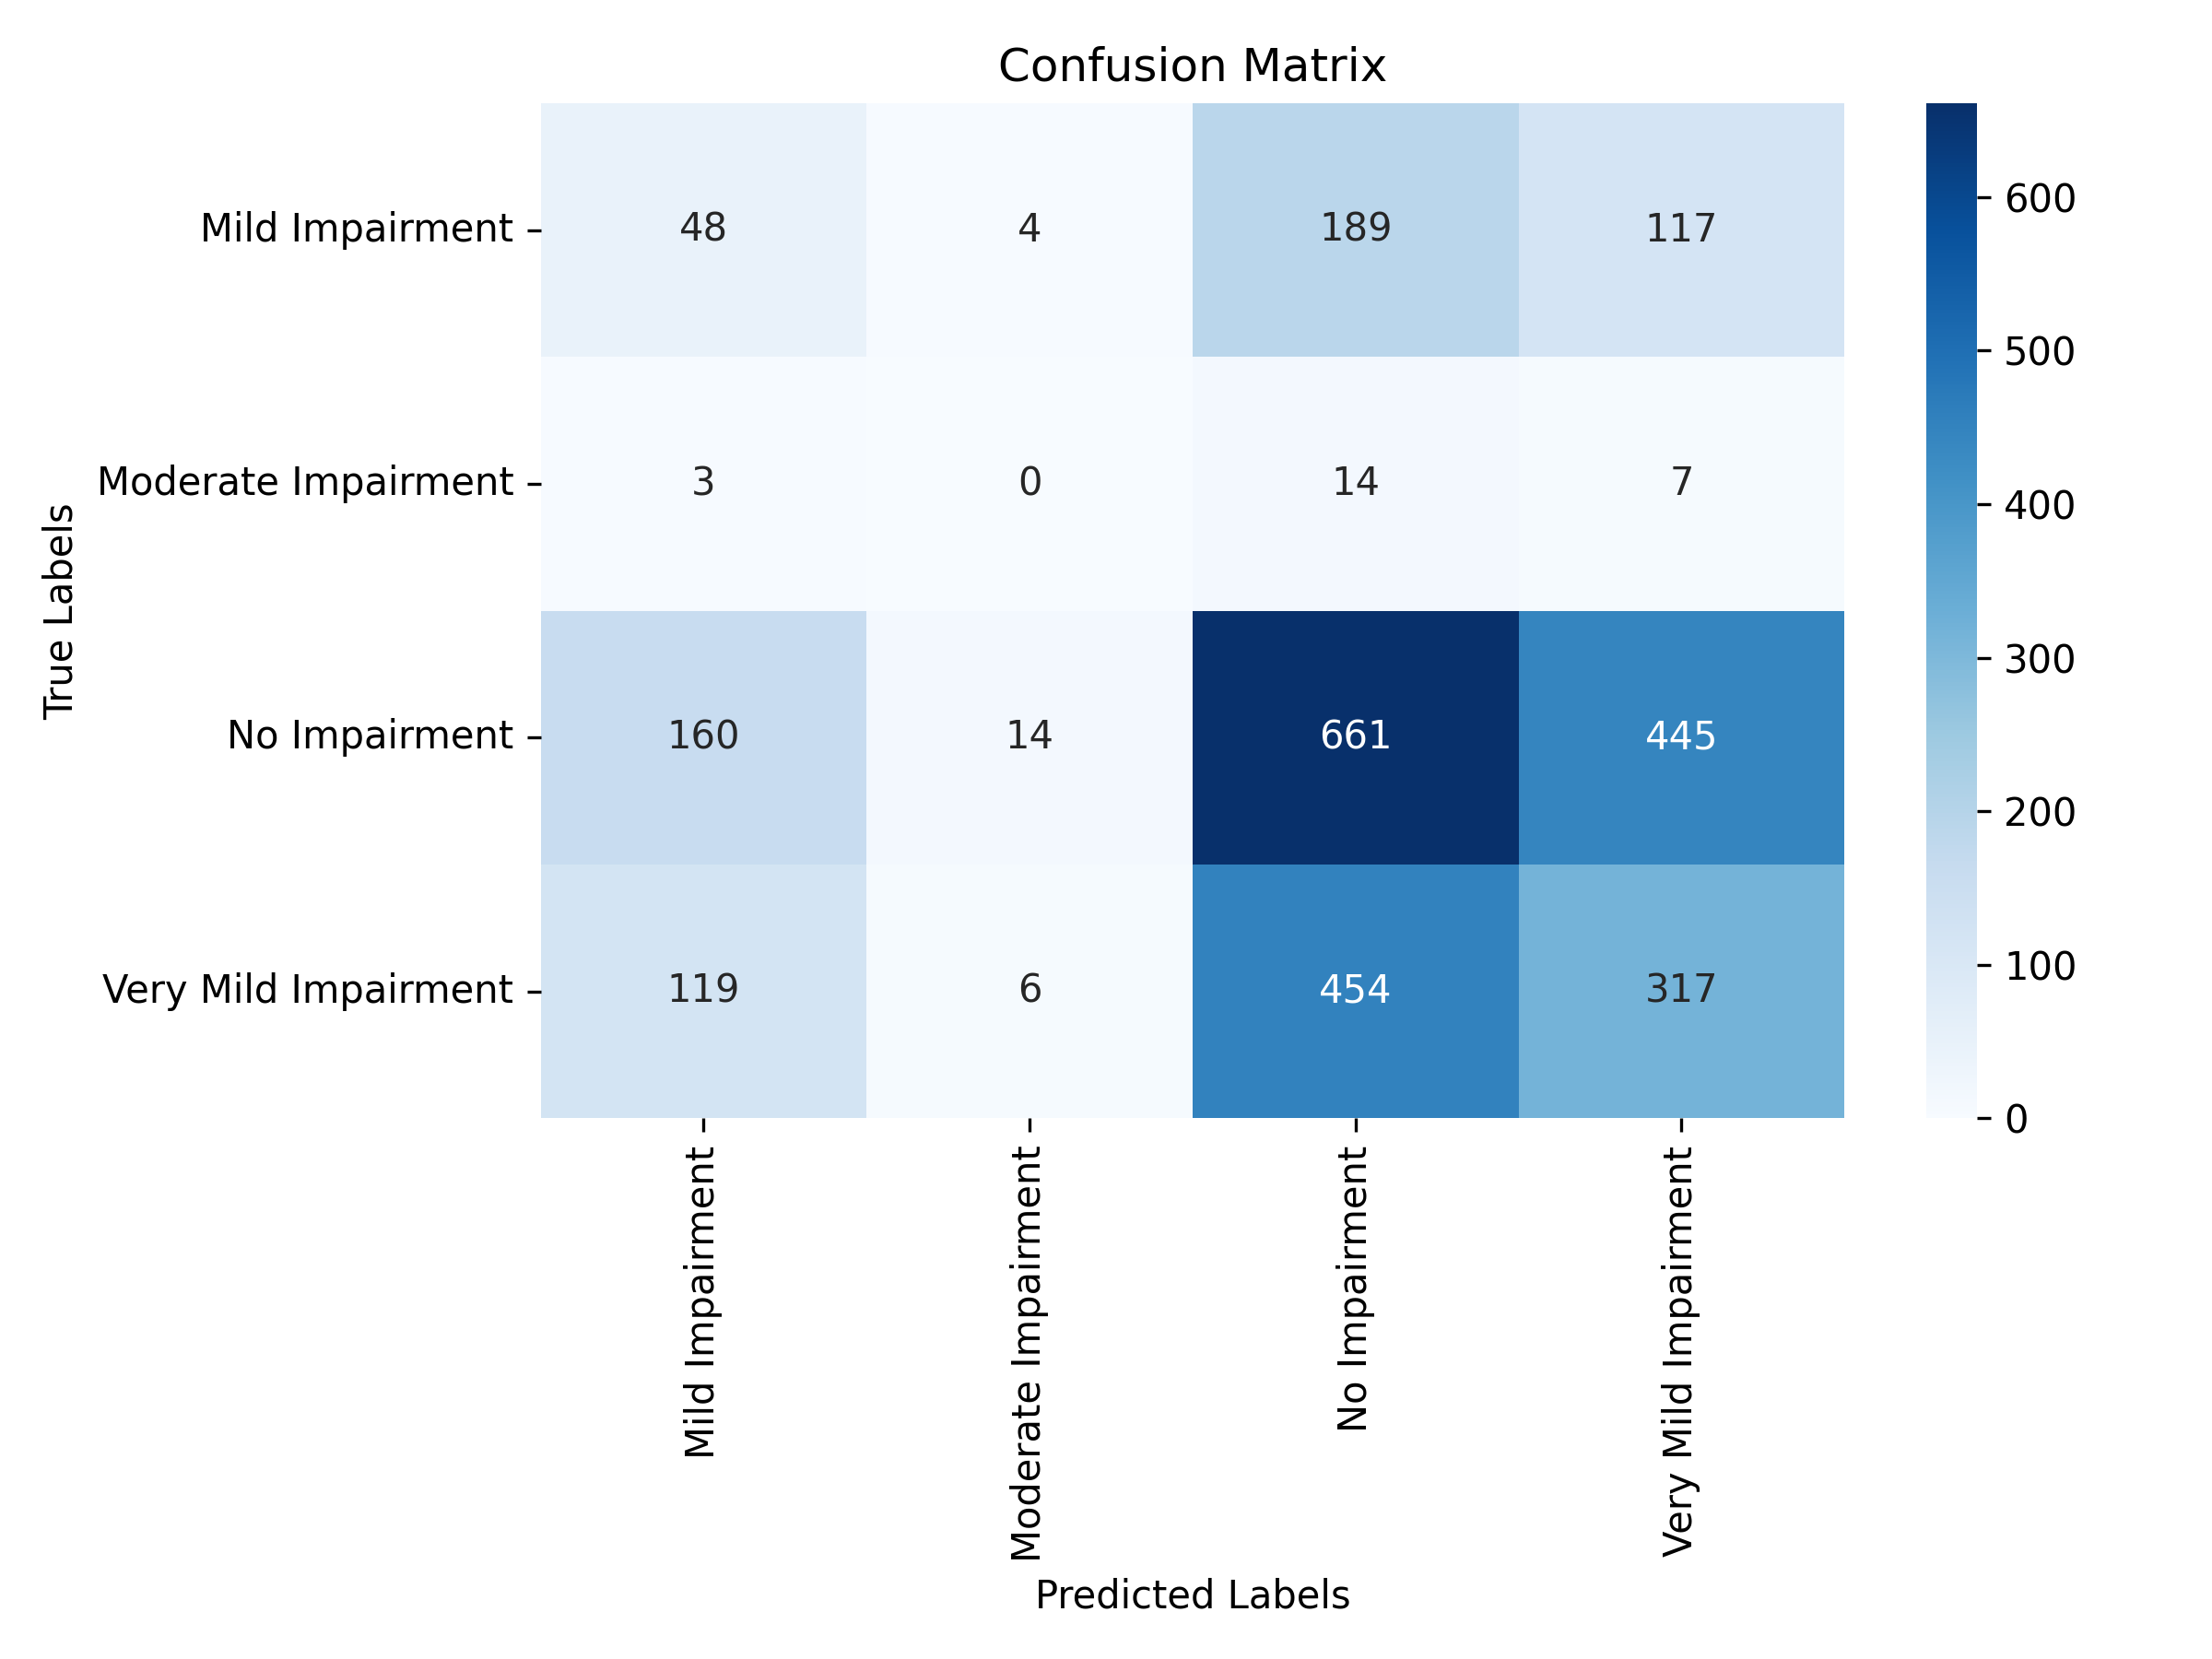


✅ All plots zipped successfully: /kaggle/working/plots.zip
💾 You can now download 'plots.zip' from the right-hand Output panel.


In [53]:
import os
from IPython.display import Image, display
import zipfile

# Directory where plots are saved
plot_dir = "/kaggle/working"
zip_path = os.path.join(plot_dir, "plots.zip")

# Display and collect all .png files
png_files = [f for f in os.listdir(plot_dir) if f.endswith(".png")]

if not png_files:
    print("⚠️ No .png files found in /kaggle/working/")
else:
    print("🖼️ Found the following plot images:\n")
    for f in png_files:
        print(" -", f)
        display(Image(filename=os.path.join(plot_dir, f)))

    # Create ZIP archive of all plots
    with zipfile.ZipFile(zip_path, "w") as zipf:
        for f in png_files:
            zipf.write(os.path.join(plot_dir, f), arcname=f)

    print(f"\n✅ All plots zipped successfully: {zip_path}")
    print("💾 You can now download 'plots.zip' from the right-hand Output panel.")
